# AllLife Bank : Personal loan campaign

### Problem Statement

AllLife Bank wants to expand its asset customer base by converting liability customers (depositors) into personal loan customers, while ensuring they remain depositors. 
To achieve this, the bank intends to leverage data-driven strategies to improve target marketing campaigns and increase the conversion rate. 
The challenge is to identify potential liability customers who are most likely to purchase personal loans by analyzing customer attributes and behavior patterns.

### Objective
To develop a predictive model that - 
- Accurately predicts whether a liability customer is likely to buy a personal loan.
- Identifies key customer attributes that significantly influence the likelihood of purchasing personal loans.
- Provides actionable insights to optimize marketing efforts by identifying high-potential customer segments for targeted campaigns.


###  Data Dictionary

The data includes various customer attributes which can be used to identify patterns. A detailed data dictionary is provided below.

ID: Customer ID

Age: Customer’s age in completed years

Experience: # years of professional experience

Income: Annual income of the customer (in thousand dollars)

ZIP Code: Home Address ZIP code.

Family: The family size of the customer

CCAvg: Average spending on credit cards per month (in thousand dollars)

Education: Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional

Mortgage: Value of house mortgage if any (in thousand dollars)

Personal_Loan: Did this customer accept the personal loan offered in the last campaign?

Securities_Account: Does the customer have a securities account with the bank?

CD_Account: Does the customer have a certificate of deposit (CD) account with the bank?

Online: Do customers use Internet banking facilities?

CreditCard: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?




### Questions to be answered
- Which customer segments have the highest or lowest likelihood to accept a personal loan?
- Which customer attributes (age, income, experience, spending, family size, etc.) most strongly influence the likelihood of accepting a personal loan?
- Are there clear behavior patterns (e.g., credit card use, online banking, securities or CD accounts) linked to loan acceptance?
- How are the features distributed? (e.g., Are income, CC spending, mortgage amounts skewed?)
- Are there strong correlations between any features? (e.g., income vs CC spending, experience vs age)
- Which features are the most important predictors for a customer buying a personal loan?
- What customer profile should the bank target in the next marketing campaign to increase personal loan uptake?
- Are there cross-sell opportunities? E.g., do customers with certain products (CD Account, Securities Account) have a higher chance to take loans?
- What marketing messages or offers could help convert borderline customers?

## Importing necessary libraries

In [1268]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To build Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [1269]:
# loading the dataset
data = pd.read_csv('/Users/ashiravi/Cisco_Lenovo_bkup_26022018/D/Training_docs/GL_UT_AI_ML/Machine_Learning/Loan_Modelling.csv')

In [1270]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

## Data Overview

### Displaying the first and last few rows of the data

In [1271]:
# viewing the first 5 rows of the data
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [1272]:
# viewing the last 5 rows of the data
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Checking the shape of the dataset

In [1273]:
# checking the shape of the data
df.shape

(5000, 14)

### Checking the data types of the columns for the dataset.

In [1274]:
# checking datatypes and number of non-null values for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


#### Observations:
All the columns in the dataset have numeric values

### Checking for missing values in the dataset

In [1275]:
# checking for null values in the data
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

In [1276]:
#Checking for na values in the data
df.isna().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

#### Observations:
There are no missing values in the dataset

### Checking for unique values

In [1277]:
# checking the number of unique values in each column
df.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIPCode                467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal_Loan            2
Securities_Account       2
CD_Account               2
Online                   2
CreditCard               2
dtype: int64

#### Observations:
There are 5000 unique ID values in the dataset which means there are no duplicates

### Checking the Statistical Summary

In [1278]:
# Look at the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


#### Observations:
- Age ranges from 23 to 67 years, with a mean around the mid 40s.
- Experience closely tracks Age, but some negative values may indicate data entry errors.
- Income varies significantly, with a mean around $73k and some high-income outliers.
- Family size ranges from 1 to 4, with most customers having small families.
- CCAvg and Mortgage also show high variability, with some customers having no mortgage or credit card spending.
- No missing values or obvious duplicates are present in the data.

### Lets check the negative values in Experience column

In [1279]:
#Lets look at Experience column with negative values
df[df['Experience'] < 0]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


**Making an assumption that negative values are wrong data entries and these numbers should have been positive values entered incorrectly. Hence replacing the negavtive values with same positive values**

In [1280]:
# Replace negative values in Experience with their absolute values
df['Experience'] = df['Experience'].abs()

In [1281]:
df.Experience.describe()

count    5000.000000
mean       20.134600
std        11.415189
min         0.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

In [1282]:
df[df['Experience'] < 0]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard


**No more negative values**

## Exploratory Data Analysis

### Many colums have categorical values. Let analyse and convert them to categorical data

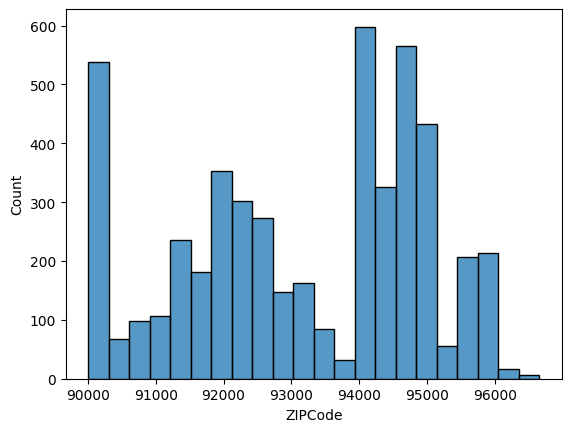

In [1283]:
sns.histplot(data=df,x='ZIPCode')
plt.show()

In [1284]:
df["ZIPCode"] = df["ZIPCode"].astype(str)
df["ZIPCode"] = df["ZIPCode"].str[0:2]
df["ZIPCode"] = df["ZIPCode"].astype("category")

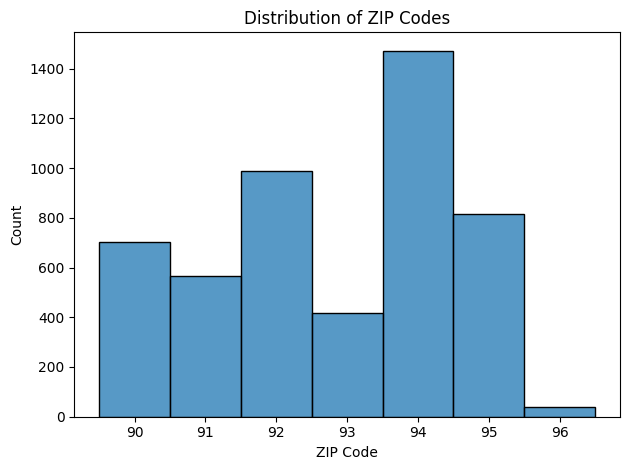

<Figure size 2000x600 with 0 Axes>

In [1285]:
sns.histplot(data=df,x='ZIPCode')
plt.title('Distribution of ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Count')
plt.tight_layout()  
plt.figure(figsize=(20, 6))
plt.show()

In [1286]:
# # Converting categorical columns to 'category' datatype
# Categorical_Columns = [
#     "Education",
#     "Personal_Loan",
#     "Securities_Account",
#     "CD_Account",
#     "Online",
#     "CreditCard",
# ]
# df[Categorical_Columns] = df[Categorical_Columns].astype("category")

In [1287]:
# # Verifying the changes made to the data types
# df.info()

### Lets look at univariate analysis of all variables

In [1288]:
#Function to perform univariate analysis on the DataFrame
def univariate_analysis_column(df, col):
    """
    Performs univariate analysis for a single column in the DataFrame.
    For numerical columns: plots histogram and boxplot.
    For categorical columns: plots countplot.
    """

    if col not in df.columns:
        print(f"Column '{col}' not found in DataFrame.")
        return

    if df[col].dtype in ['int64', 'float64']:
        # plt.figure(figsize=(10,4))
        # plt.subplot(1,2,1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Histogram of {col}')
        # plt.subplot(1,2,2)
        plt.show()
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8,4))
        ax = sns.countplot(x=df[col])
        plt.title(f'Countplot of {col}')
        for p in ax.patches:
            count = p.get_height()
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(f'{count}', (x, y), ha='center', va='bottom')
        plt.show()

#### Analysis of Age

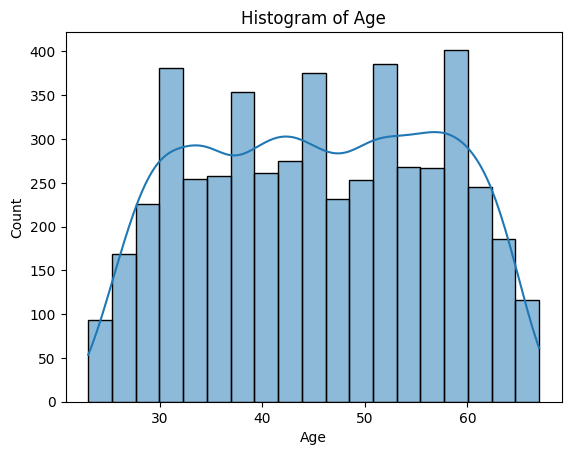

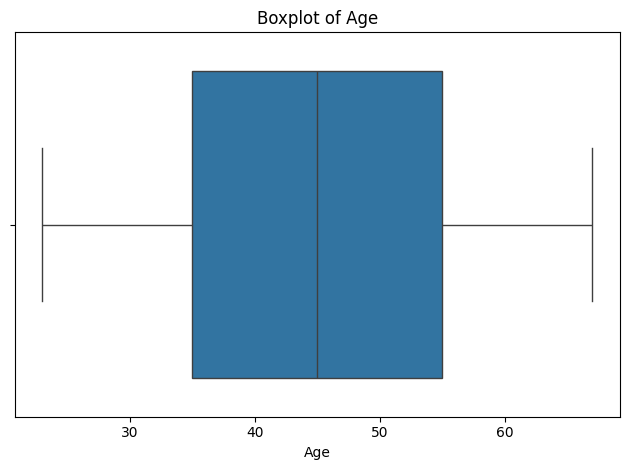

In [1289]:
# Performing univariate analysis on the 'Age' column
univariate_analysis_column(df, 'Age')

#### Observations:
The histogram and boxplot for the 'Age' column show that the age distribution of customers evenly distributed. Most customers fall within the 30 to 60 age range. 

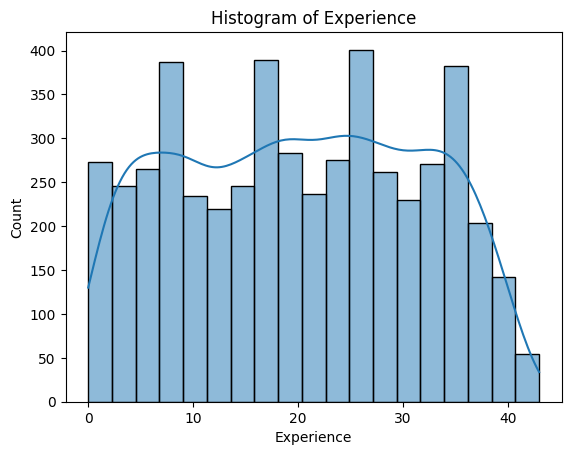

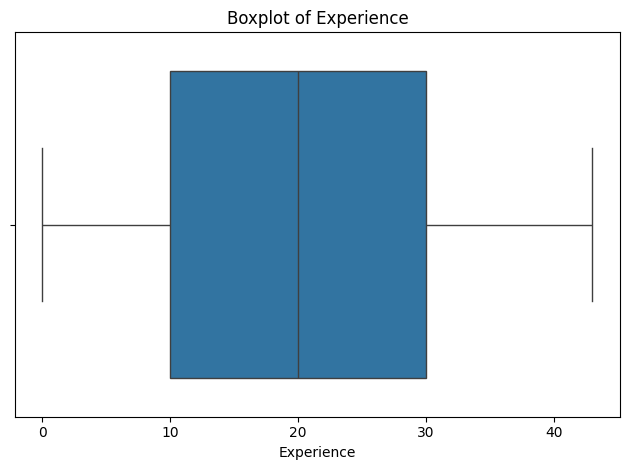

In [1290]:
# Performing univariate analysis on the 'Experience'
univariate_analysis_column(df, 'Experience')

#### Observations:
The histogram and boxplot for the 'Experience' column show that most customers have professional experience ranging from 0 to 40 years, with a distribution similar to age. There are no negative values after cleaning, and the data is slightly right-skewed, indicating a few customers with very high experience.

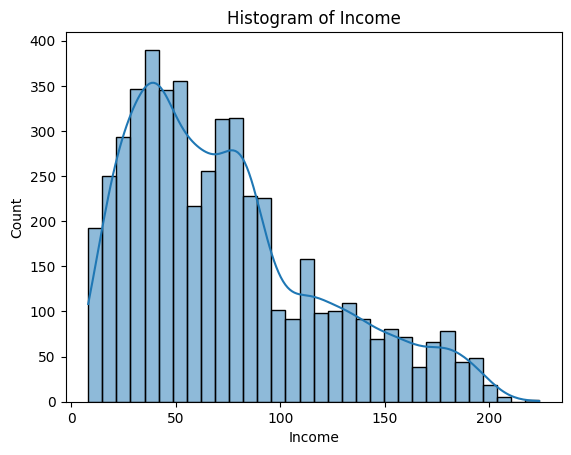

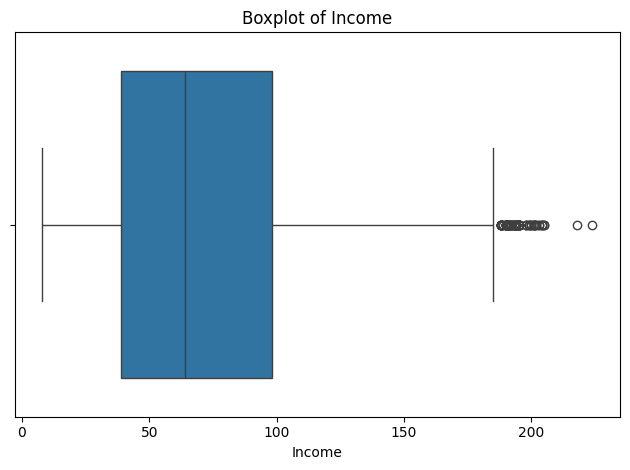

In [1291]:
# Performing univariate analysis on the 'Income'
univariate_analysis_column(df, 'Income')

#### Observations:
The above graphs shows that most customers have annual incomes clustered at lower values. 
25 to 75% are falling in income range of around 40k to below 100K $ with median around 70K.
There are few high-income outliers and hence the graph is right skewed.

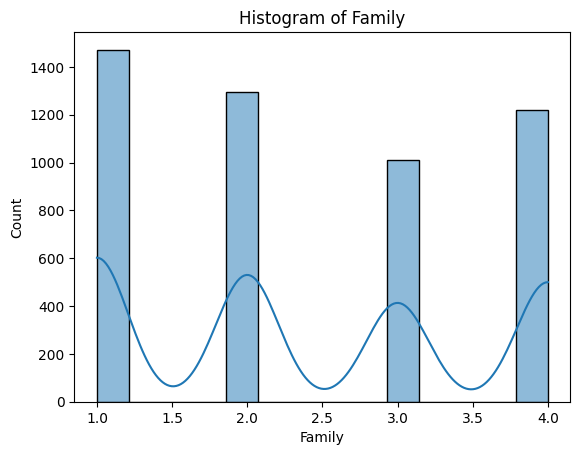

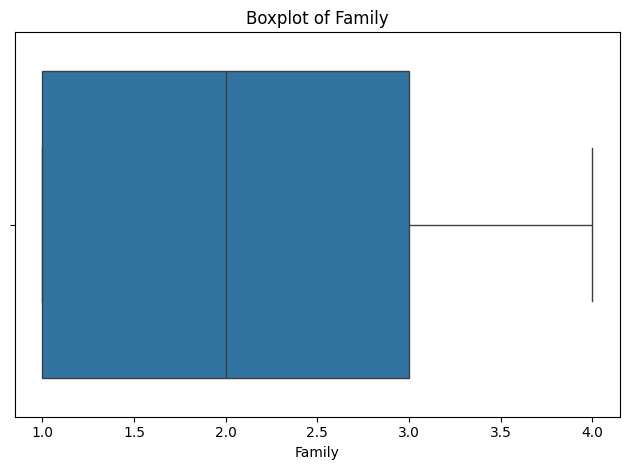

In [1292]:
# Performing univariate analysis on the 'Family'
univariate_analysis_column(df, 'Family')

#### Observations:
The graph shows family size 1 and 2 being the most common. There are very few customers with larger family sizes, indicating that the bank's customer base is primarily composed of small families.

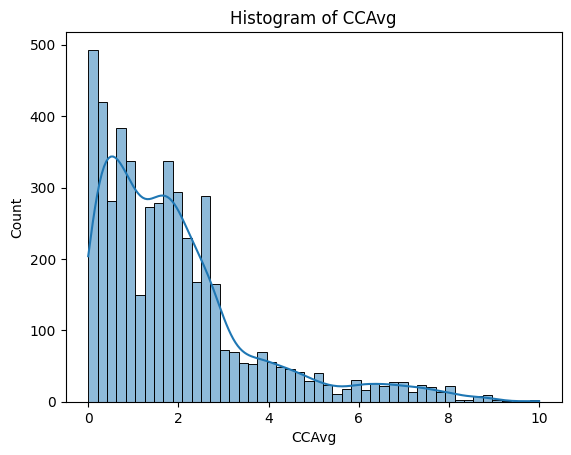

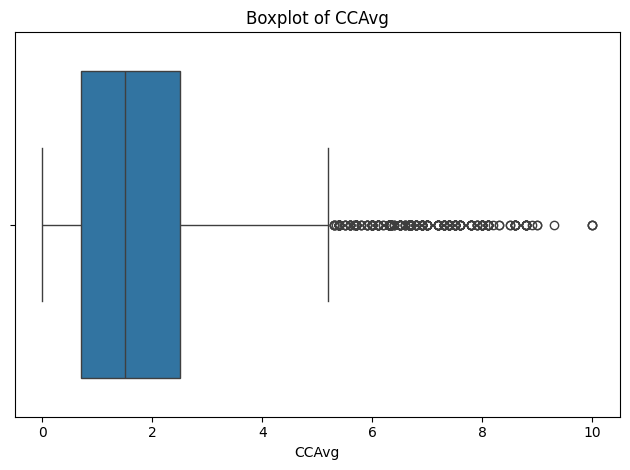

In [1293]:
# Performing univariate analysis on the 'CCAvg'
univariate_analysis_column(df, 'CCAvg')

#### Observations:
Most customers have low average monthly credit card spending. The graph is right skewed indicating a few customers with very high spending.

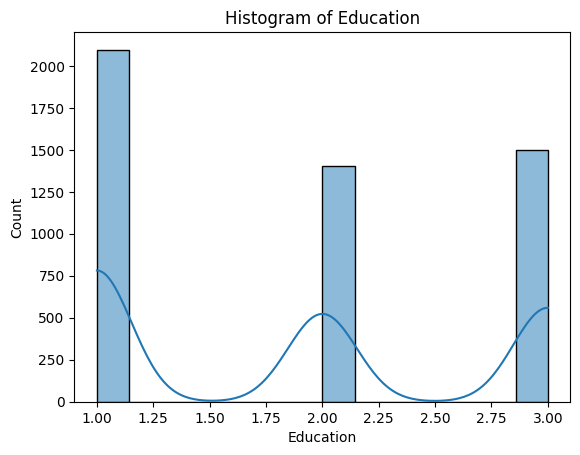

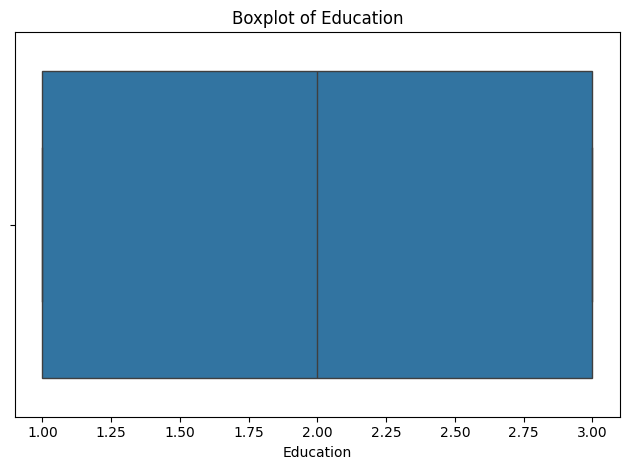

In [1294]:
# Performing univariate analysis on the 'Education'
univariate_analysis_column(df, 'Education')

#### Observations:

Most customers are undergraduates, followed by graduates and then advanced/professional degree holders. This indicates that the bank's customer base is primarily composed of individuals with lower to mid-level education. There are customers having advanced degrees also.

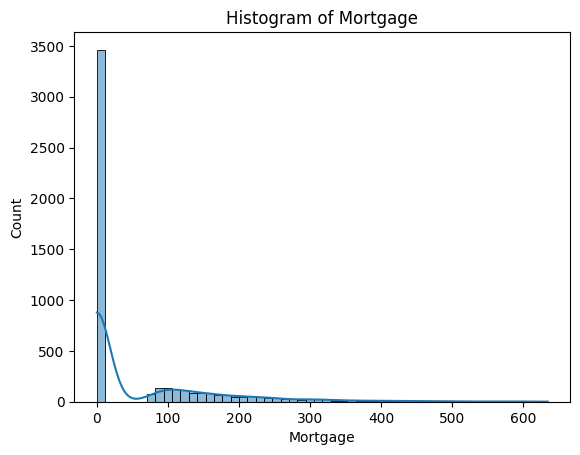

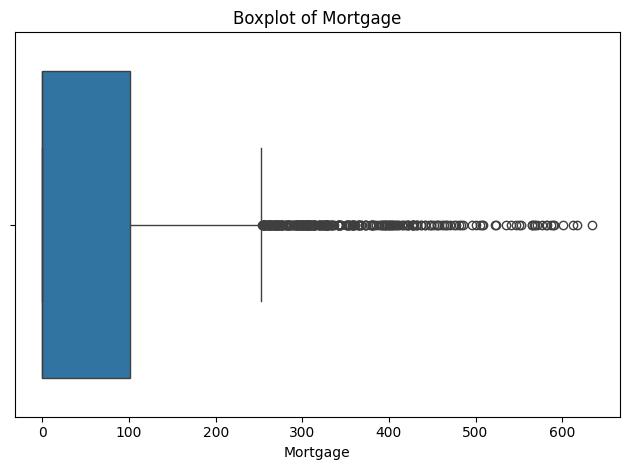

In [1295]:
# Performing univariate analysis on the 'Mortgage'
univariate_analysis_column(df, 'Mortgage')

#### Observations:
Most customers have a mortgage value of zero, indicating that a large portion of the customer base does not have a house mortgage. Among those who do, the mortgage amounts are widely spread, with a few customers having significantly higher mortgage values. The distribution is highly right-skewed.

### Bivariate Analysis

Bivariate analysis examines the relationships among three or more variables simultaneously. Common techniques include pairplots, correlation matrices, and heatmaps to visualize interactions and dependencies between variables.

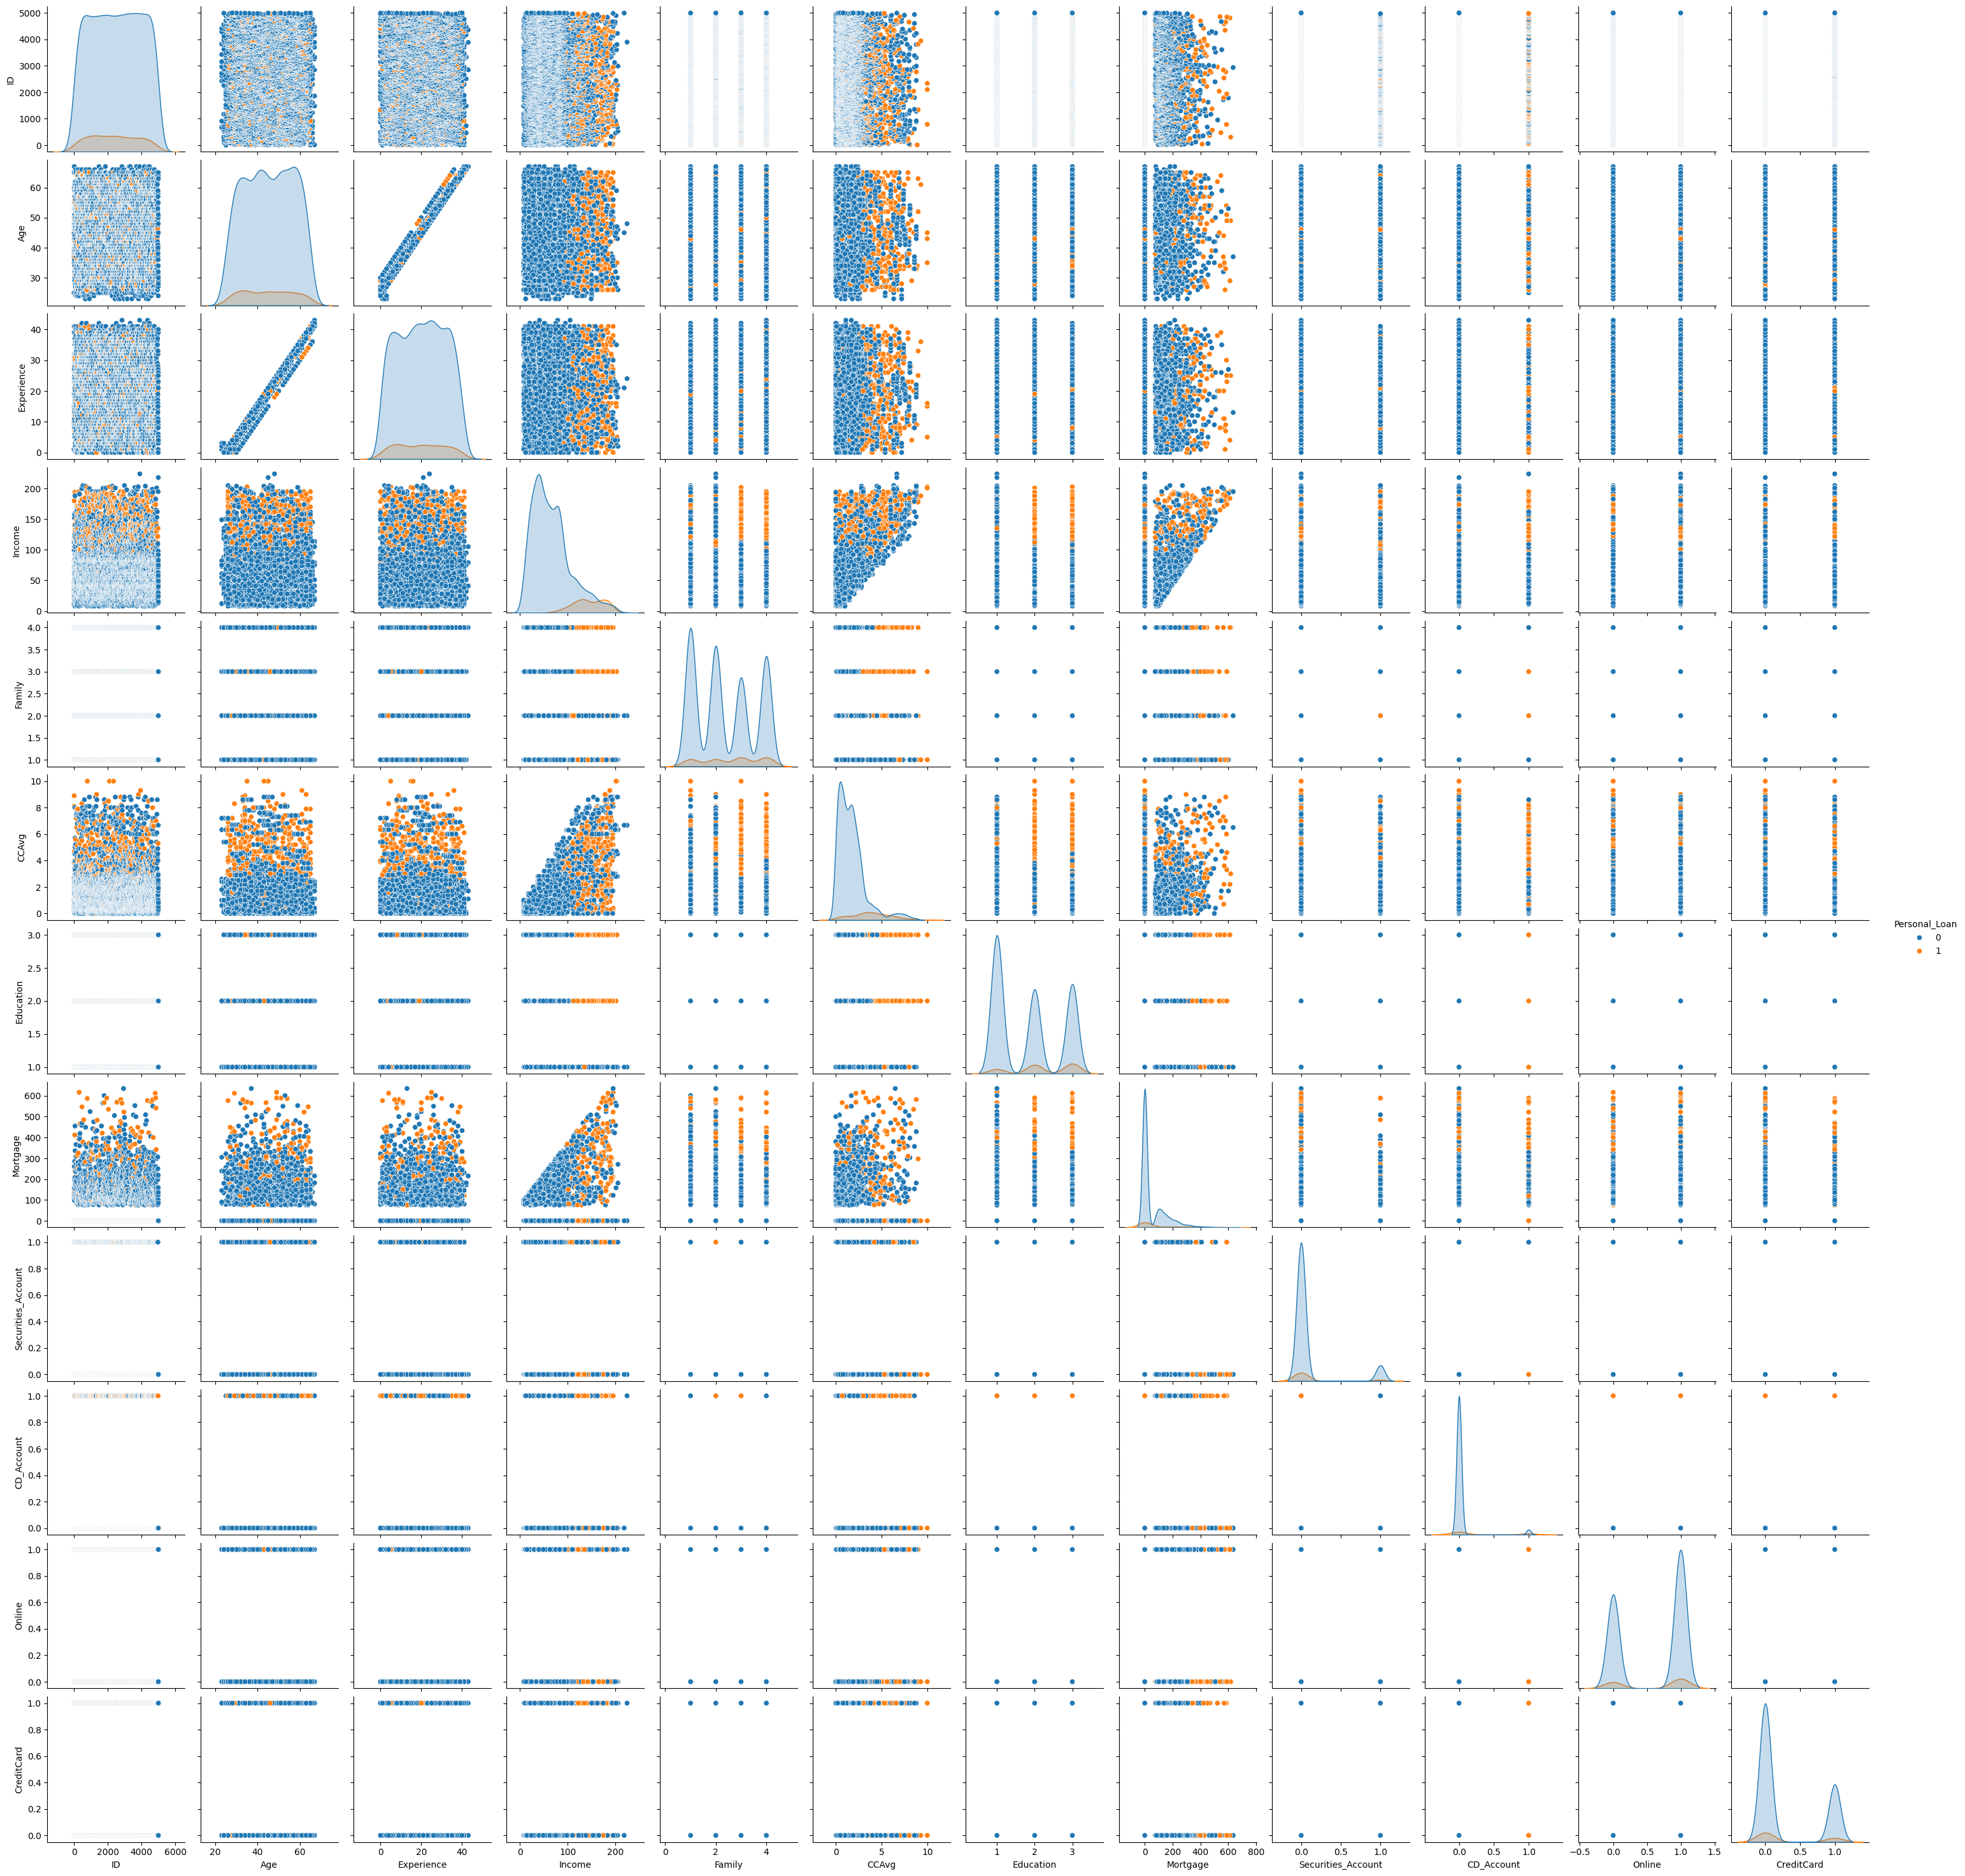

In [1296]:
# Pairplot to visualize relationships between numerical variables colored by Personal_Loan
sns.pairplot(df, hue="Personal_Loan")
plt.show()

#### Pairplot Summary

The pairplot visualizes the relationships between numerical variables, colored by personal loan acceptance. Key observations:
- Customers who accepted personal loans tend to have higher income and CCAvg (credit card spending).
- There is a visible separation in the income and CCAvg distributions between those who accepted and did not accept the loan.
- Age and Experience are highly correlated, as expected.
- Most variables show some overlap, but Income and CCAvg are the most distinguishing features for personal loan acceptance.

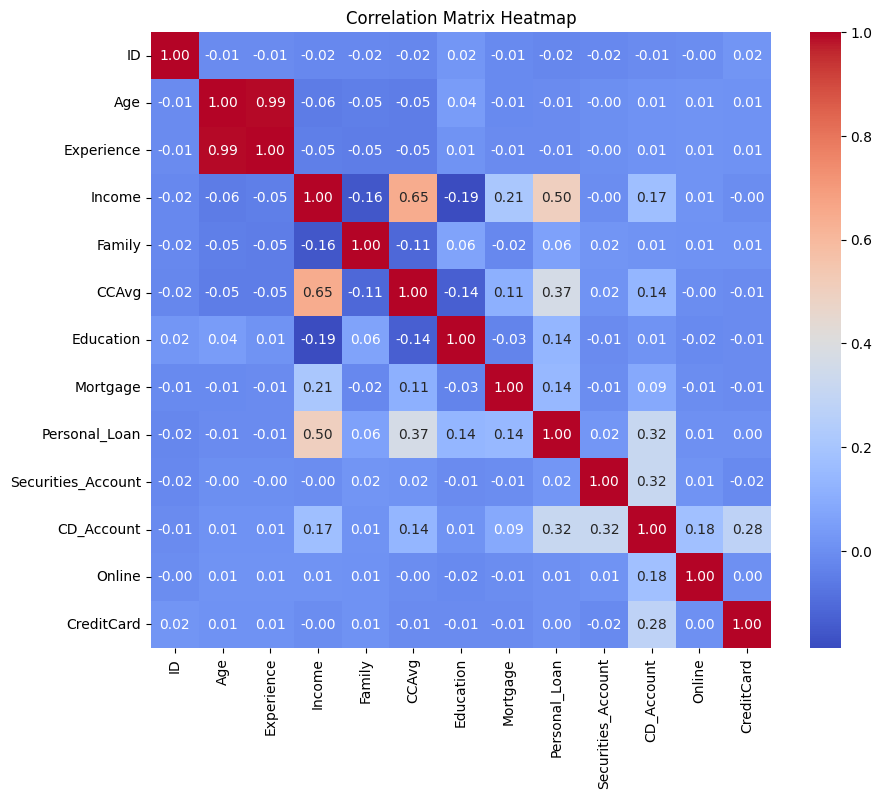

In [1297]:
# Correlation matrix and heatmap for numerical features
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

#### Heatmap Summary

- Age and Experience are highly positively correlated, as expected.
- Income shows a strong positive correlation with CCAvg (credit card spending) and a moderate correlation with Personal_Loan acceptance.
- CCAvg is also moderately correlated with Personal_Loan.
- Most other variables show weak or negligible correlations.
- There are no strong negative correlations among the features.
- At this point these insights suggest that Income and CCAvg could be important predictors for personal loan acceptance. Let see.

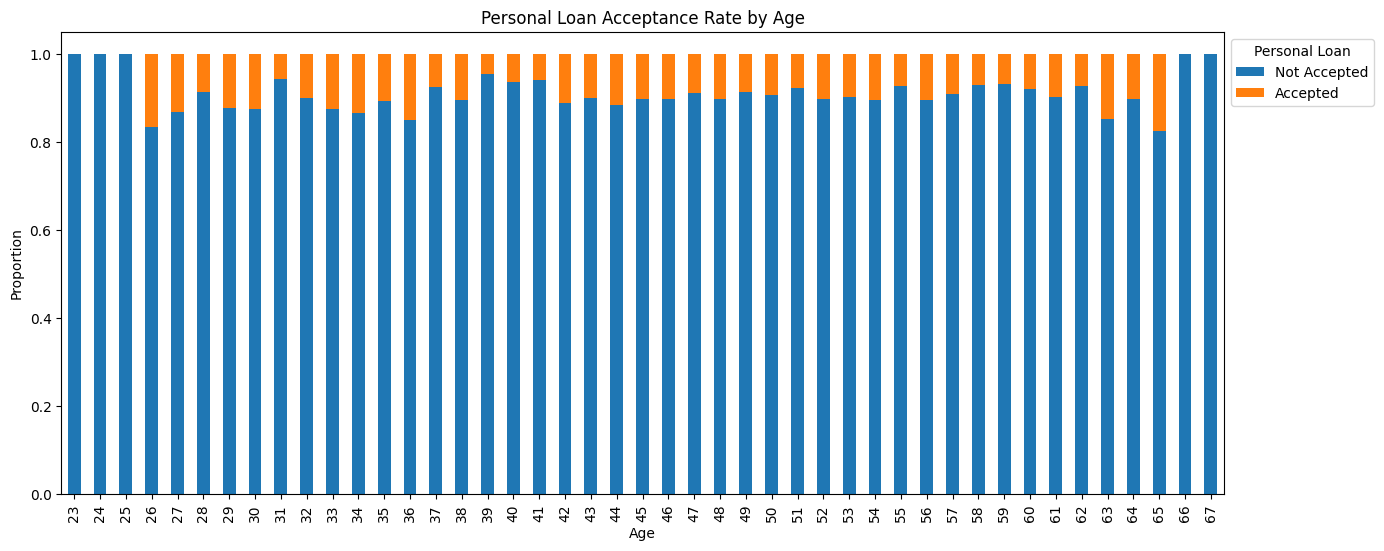

In [1298]:
# Crosstab stacked bar graph between age and personal loan acceptance
pd.crosstab(df['Age'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(15, 6))
plt.title('Personal Loan Acceptance Rate by Age')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

#### Observations:
The graph shows middle-aged customers have a higher likelihood of accepting a personal loan compared to younger and older customers. The acceptance in middle is fairly spread out though

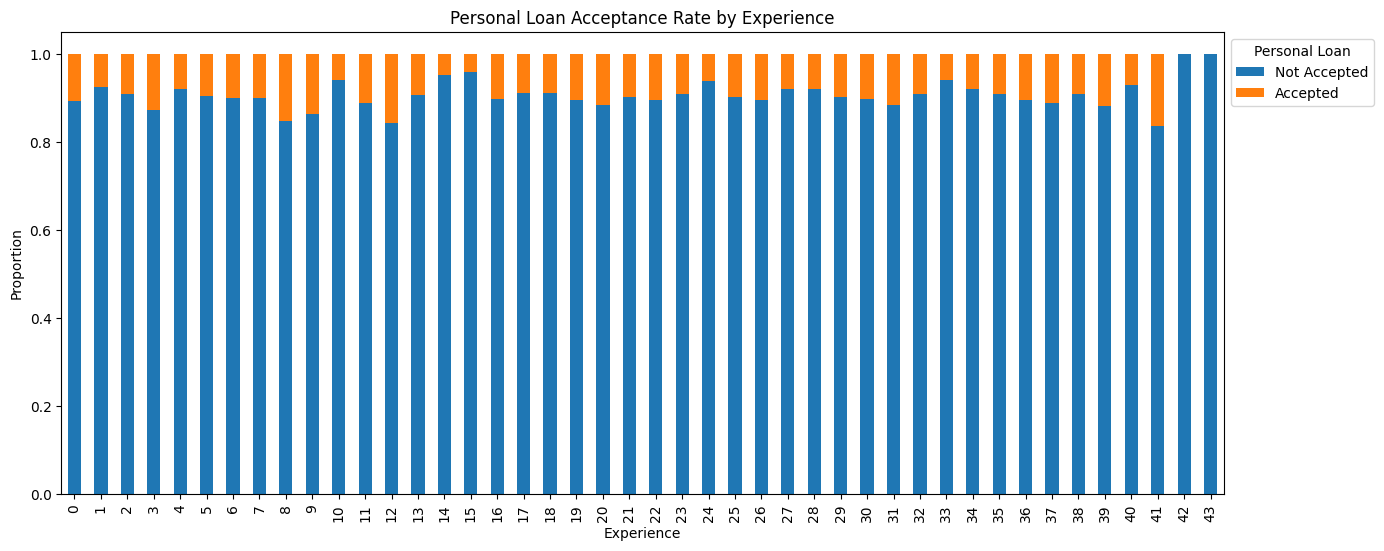

In [1299]:
# Crosstab stacked bar graph between experience and personal loan acceptance
pd.crosstab(df['Experience'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(15, 6))
plt.title('Personal Loan Acceptance Rate by Experience')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
The graph is evenly spread out with customers with very high experience generally have a lower likelihood of accepting a personal loan.

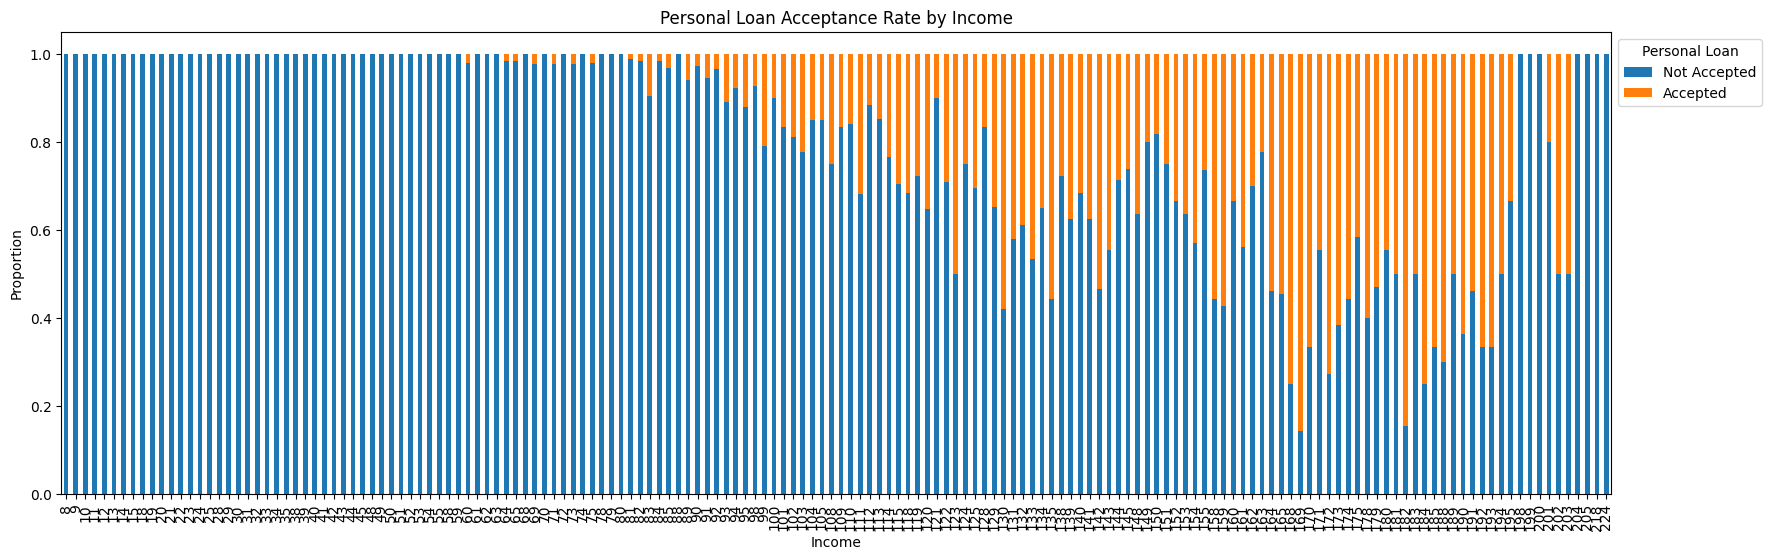

In [1300]:
# Crosstab stacked bar graph between income and personal loan acceptance
pd.crosstab(df['Income'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(20, 6))
plt.title('Personal Loan Acceptance Rate by Income')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers with higher income have a significantly greater likelihood of accepting a personal loan. The acceptance rate increases as income rises, indicating that income is a strong predictor for personal loan uptake.

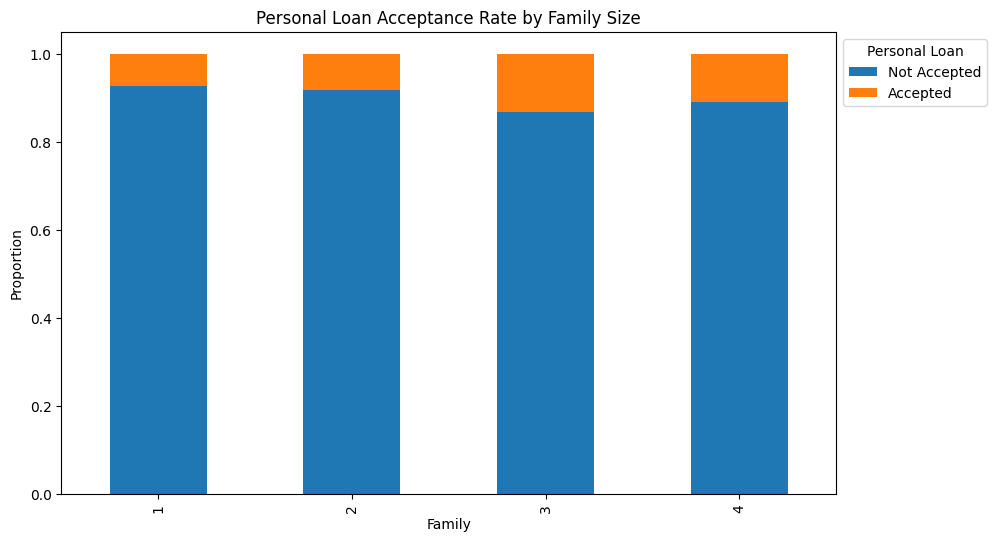

In [1301]:
# Crosstab stacked bar graph between family and personal loan acceptance
pd.crosstab(df['Family'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Personal Loan Acceptance Rate by Family Size')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers with a family size of 3 or 4 have a higher likelihood of accepting a personal loan compared to those with smaller family sizes. The acceptance rate looks lower for family size of 1 and 2 as compared with family size 3 and 4.

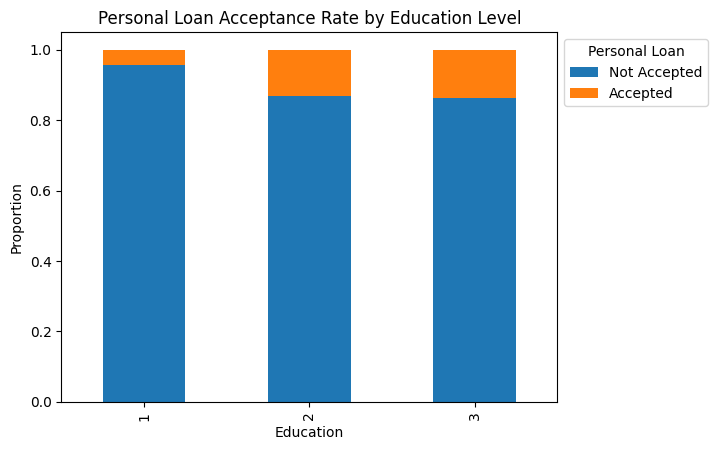

In [1302]:
# Crosstab stacked bar graph between education and personal loan acceptance
pd.crosstab(df['Education'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Personal Loan Acceptance Rate by Education Level')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers with higher education levels (Graduate and Advanced/Professional) have a greater likelihood of accepting a personal loan compared to undergraduates.

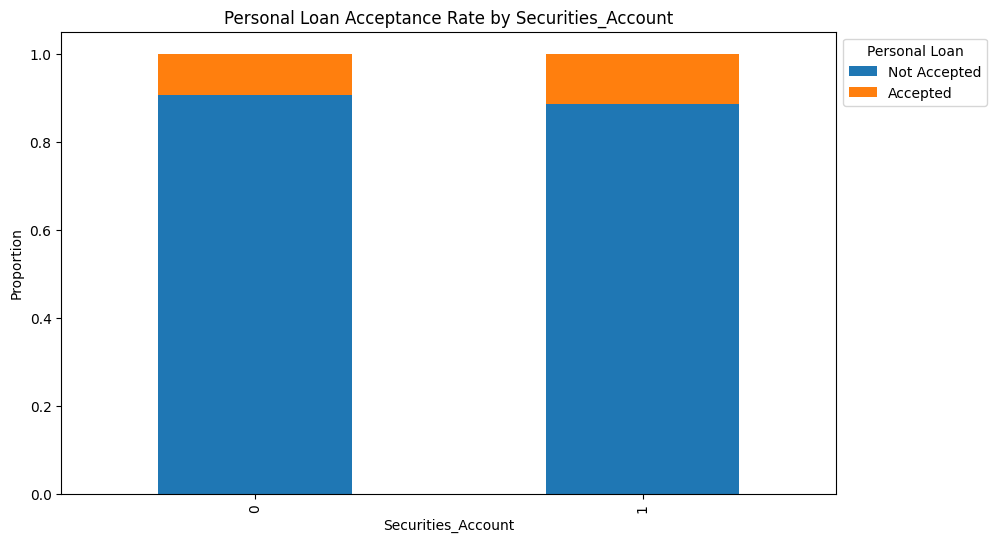

In [1303]:
# Crosstab stacked bar graph between securities account and personal loan acceptance
pd.crosstab(df['Securities_Account'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Personal Loan Acceptance Rate by Securities_Account')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
There seems to be positive corelation between securities account and personal loan acceptance. Customers who have a securities account with the bank are more likely to accept a personal loan compared to those who do not have a securities account.

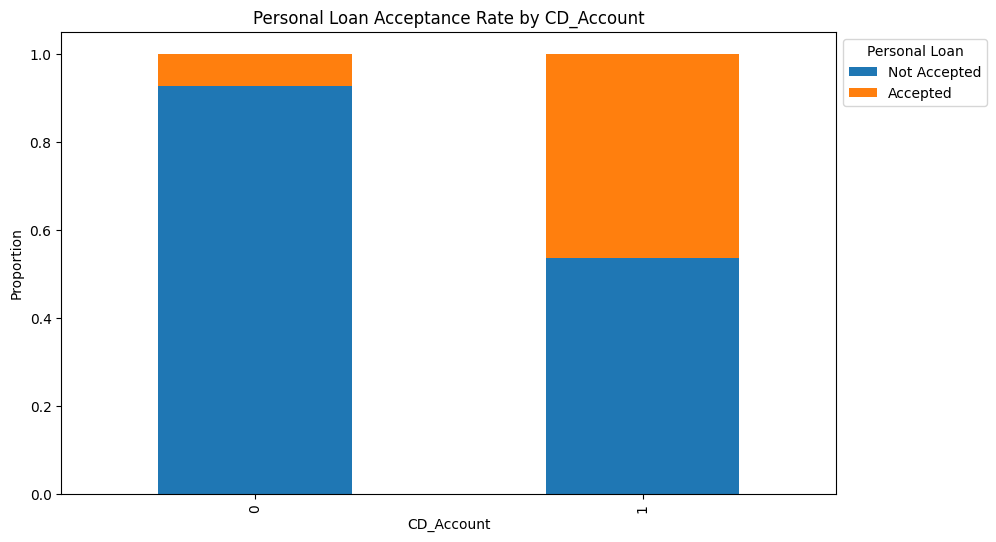

In [1304]:
# Crosstab stacked bar graph between CD account and personal loan acceptance
pd.crosstab(df['CD_Account'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Personal Loan Acceptance Rate by CD_Account')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers who have a CD account with the bank are much more likely to accept a personal loan compared to those who do not have a CD account.

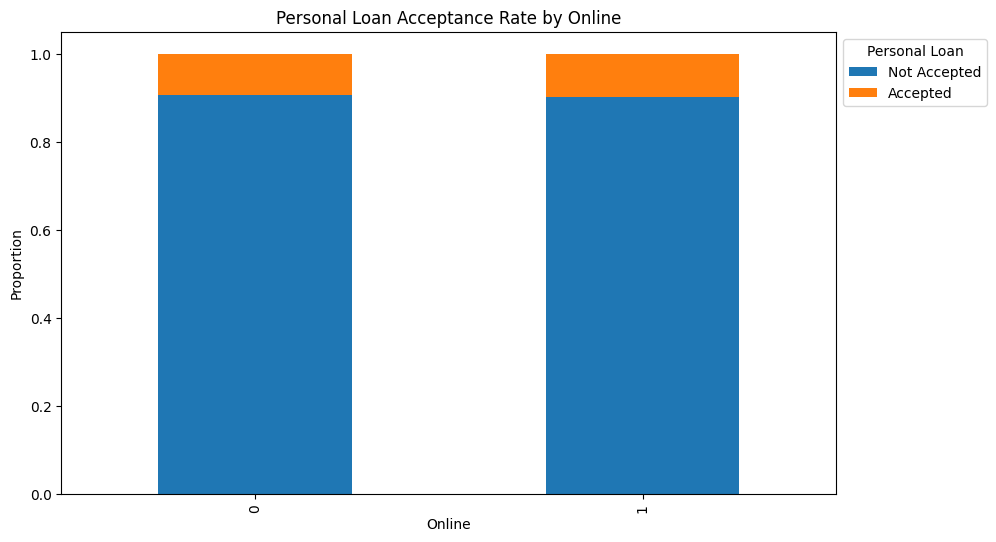

In [1305]:
# Crosstab stacked bar graph between online and personal loan acceptance
pd.crosstab(df['Online'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Personal Loan Acceptance Rate by Online')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers who use online banking facilities have a slightly higher likelihood of accepting a personal loan compared to those who do not use online banking. However, the difference is not as pronounced as with other features like income or CD account.

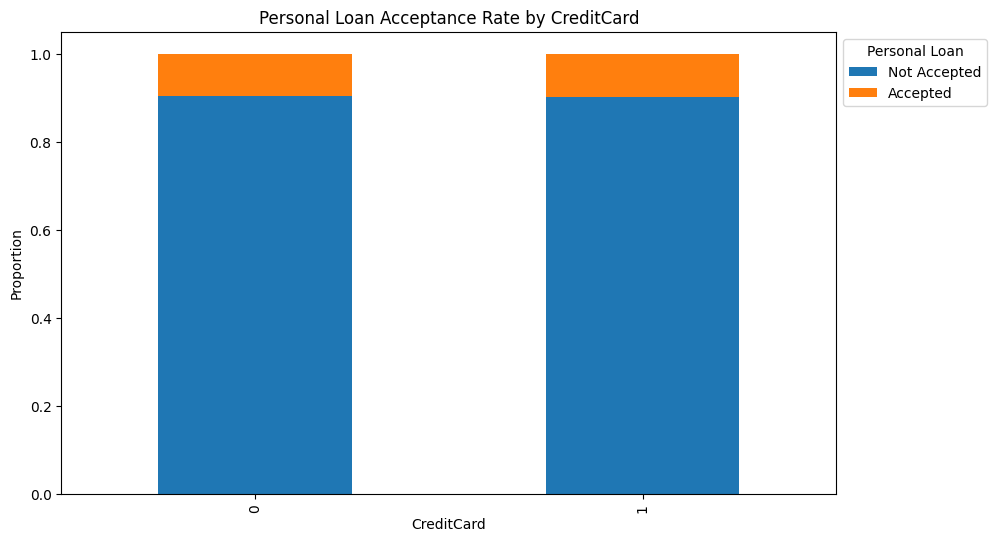

In [1306]:
# Crosstab stacked bar graph between CreditCard and personal loan acceptance
pd.crosstab(df['CreditCard'], df['Personal_Loan'], normalize='index').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Personal Loan Acceptance Rate by CreditCard')
plt.ylabel('Proportion')
plt.legend(title='Personal Loan', labels=['Not Accepted', 'Accepted'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### Observations:
Customers who use credit cards issued by other banks are slightly more likely to accept a personal loan compared to those who do not use such credit cards. However, the difference is not as pronounced as with features like income or CD account.

## Data pre-processing
- Missing Value Treatment - The negative experience values were treated already above. There are no missing values.
- Outlier Detection will be checked.
- Feature Engineering will be done.
- Data preparation for modelling will be done.

### Outlier detection

In [1307]:
# Outlier detection using IQR method for all numerical columns
def detect_outliers_iqr(df):
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = outliers.shape[0]
        print(f"{col}: {outliers.shape[0]} outliers")
    return outlier_summary

outlier_counts = detect_outliers_iqr(df)


ID: 0 outliers
Age: 0 outliers
Experience: 0 outliers
Income: 96 outliers
Family: 0 outliers
CCAvg: 324 outliers
Education: 0 outliers
Mortgage: 291 outliers
Personal_Loan: 480 outliers
Securities_Account: 522 outliers
CD_Account: 302 outliers
Online: 0 outliers
CreditCard: 0 outliers


#### Observations on Outliers

- Outlier detection reveals that features such as Income, CCAvg, and Mortgage have a notable number of outliers, primarily on the higher end.
- These outliers likely represent genuine high-value customers rather than data entry errors, as supported by the business context.
- Removing or capping these outliers may result in loss of valuable information about key customer segments that are most relevant for personal loan targeting.
- Therefore, it is recommended not to treat or remove these outliers at this stage, as they provide important insights for modeling and business strategy.

### Data preparation and feature Engineering on DataFrame


In [1308]:
#Remove the personal loan variable
X = df.drop(["Personal_Loan"], axis=1)
y = df["Personal_Loan"]

In [1309]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ID                  5000 non-null   int64   
 1   Age                 5000 non-null   int64   
 2   Experience          5000 non-null   int64   
 3   Income              5000 non-null   int64   
 4   ZIPCode             5000 non-null   category
 5   Family              5000 non-null   int64   
 6   CCAvg               5000 non-null   float64 
 7   Education           5000 non-null   int64   
 8   Mortgage            5000 non-null   int64   
 9   Securities_Account  5000 non-null   int64   
 10  CD_Account          5000 non-null   int64   
 11  Online              5000 non-null   int64   
 12  CreditCard          5000 non-null   int64   
dtypes: category(1), float64(1), int64(11)
memory usage: 474.1 KB


In [1310]:
# Convert categorical variables to dummy
X = pd.get_dummies(X, columns=["Education"], drop_first=True)
X = X.astype(float)
X.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Education_2,Education_3
0,1.0,25.0,1.0,49.0,91.0,4.0,1.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,45.0,19.0,34.0,90.0,3.0,1.5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,39.0,15.0,11.0,94.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,35.0,9.0,100.0,94.0,1.0,2.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5.0,35.0,8.0,45.0,91.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [1311]:
# Split the data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3500, 14)
Test shape: (1500, 14)


## Model Building - Decision Tree

### 1. Define Model Evaluation Criterion

We will use accuracy, precision, recall, F1-score, and confusion matrix to evaluate model performance. Since the business wants to maximize conversions without targeting uninterested customers, precision and recall are both important.

In [1312]:
# Instantiate and train a basic Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on train and test
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Evaluation function
def print_metrics(y_true, y_pred, dataset="Test"):
    print(f"{dataset} Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(f"{dataset} Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"{dataset} Recall: {recall_score(y_true, y_pred):.3f}")
    print(f"{dataset} F1 Score: {f1_score(y_true, y_pred):.3f}")
    print(f"{dataset} Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")
    print(classification_report(y_true, y_pred))

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

Train Accuracy: 1.000
Train Precision: 1.000
Train Recall: 1.000
Train F1 Score: 1.000
Train Confusion Matrix:
[[3164    0]
 [   0  336]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3164
           1       1.00      1.00      1.00       336

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500

Test Accuracy: 0.976
Test Precision: 0.860
Test Recall: 0.896
Test F1 Score: 0.878
Test Confusion Matrix:
[[1335   21]
 [  15  129]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1356
           1       0.86      0.90      0.88       144

    accuracy                           0.98      1500
   macro avg       0.92      0.94      0.93      1500
weighted avg       0.98      0.98      0.98      1500



### 2. Model Performance

- The unpruned Decision Tree may overfit, showing high train accuracy but lower test accuracy.
- Review precision and recall to understand trade-offs between targeting more likely converters and minimizing false positives.

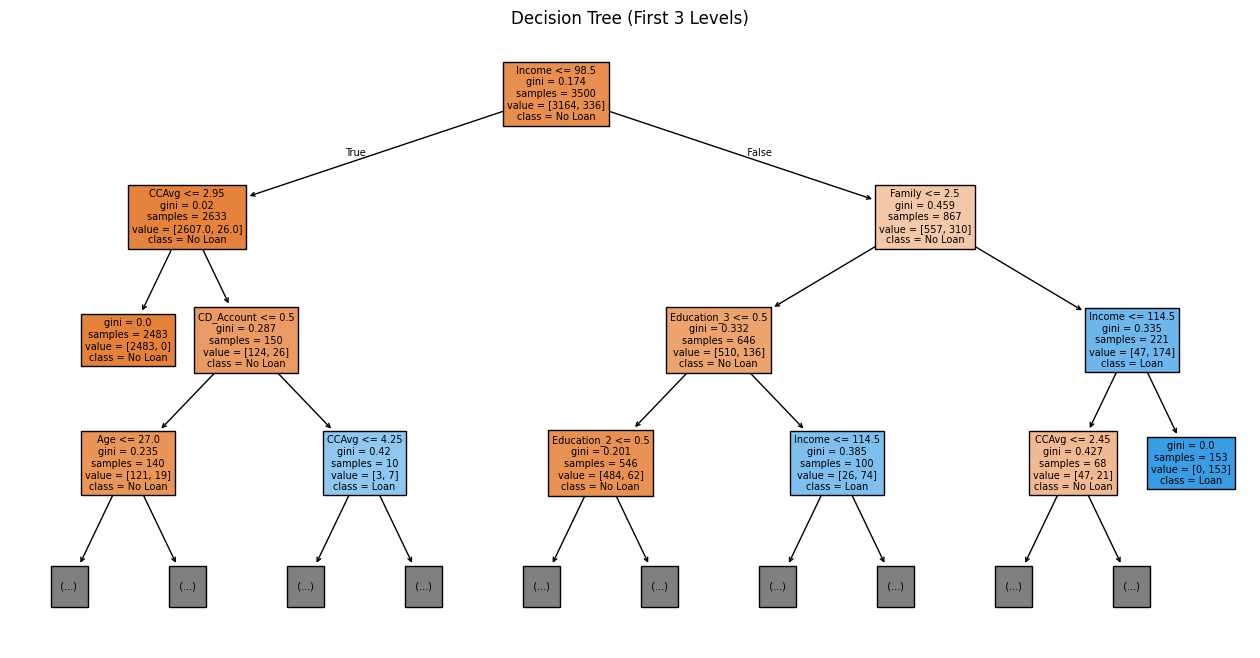

In [1313]:
# Visualize the decision tree (limited depth for clarity)
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=X_train.columns, class_names=["No Loan", "Loan"], filled=True, max_depth=3)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

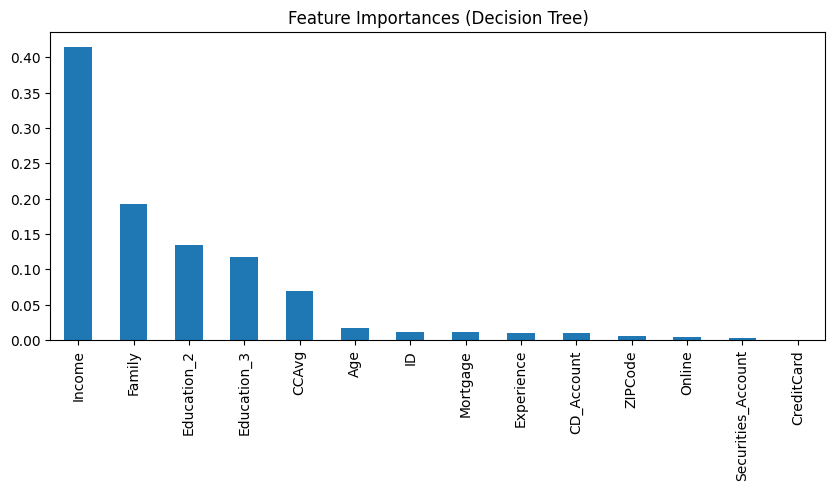

In [1314]:
# Feature importance
importances = pd.Series(dt.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Feature Importances (Decision Tree)")
plt.show()

## Model Performance Evaluation and Improvement

### 1. Improve Model Performance by Pruning

#### Pre-Pruning (limit tree depth)

In [1315]:
# Pre-pruning: limit max_depth
dt_prepruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_prepruned.fit(X_train, y_train)
y_test_pred_pre = dt_prepruned.predict(X_test)
print_metrics(y_test, y_test_pred_pre, "Test (Pre-pruned)")

Test (Pre-pruned) Accuracy: 0.979
Test (Pre-pruned) Precision: 0.850
Test (Pre-pruned) Recall: 0.944
Test (Pre-pruned) F1 Score: 0.895
Test (Pre-pruned) Confusion Matrix:
[[1332   24]
 [   8  136]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1356
           1       0.85      0.94      0.89       144

    accuracy                           0.98      1500
   macro avg       0.92      0.96      0.94      1500
weighted avg       0.98      0.98      0.98      1500



#### Post-Pruning (cost complexity pruning)

In [1316]:
# Post-pruning: use cost complexity pruning
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Try several alphas and pick the best
best_alpha = None
best_f1 = 0
for alpha in ccp_alphas:
    dt_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_postpruned.fit(X_train, y_train)
    y_pred = dt_postpruned.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

# Fit final post-pruned model
dt_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_postpruned.fit(X_train, y_train)
y_test_pred_post = dt_postpruned.predict(X_test)
print_metrics(y_test, y_test_pred_post, "Test (Post-pruned)")

Test (Post-pruned) Accuracy: 0.985
Test (Post-pruned) Precision: 0.942
Test (Post-pruned) Recall: 0.903
Test (Post-pruned) F1 Score: 0.922
Test (Post-pruned) Confusion Matrix:
[[1348    8]
 [  14  130]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1356
           1       0.94      0.90      0.92       144

    accuracy                           0.99      1500
   macro avg       0.97      0.95      0.96      1500
weighted avg       0.99      0.99      0.99      1500



### 2. Compare Model Performances

- F1 score of post pruned model has better F1 score hence choosing post pruned model

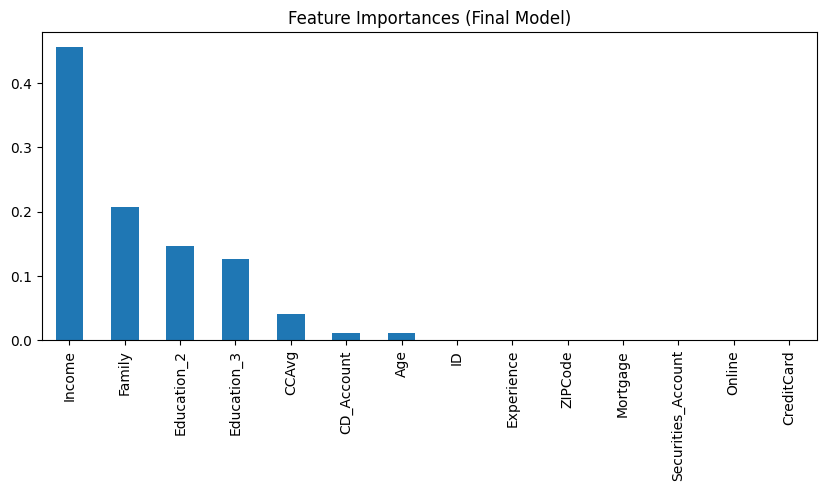

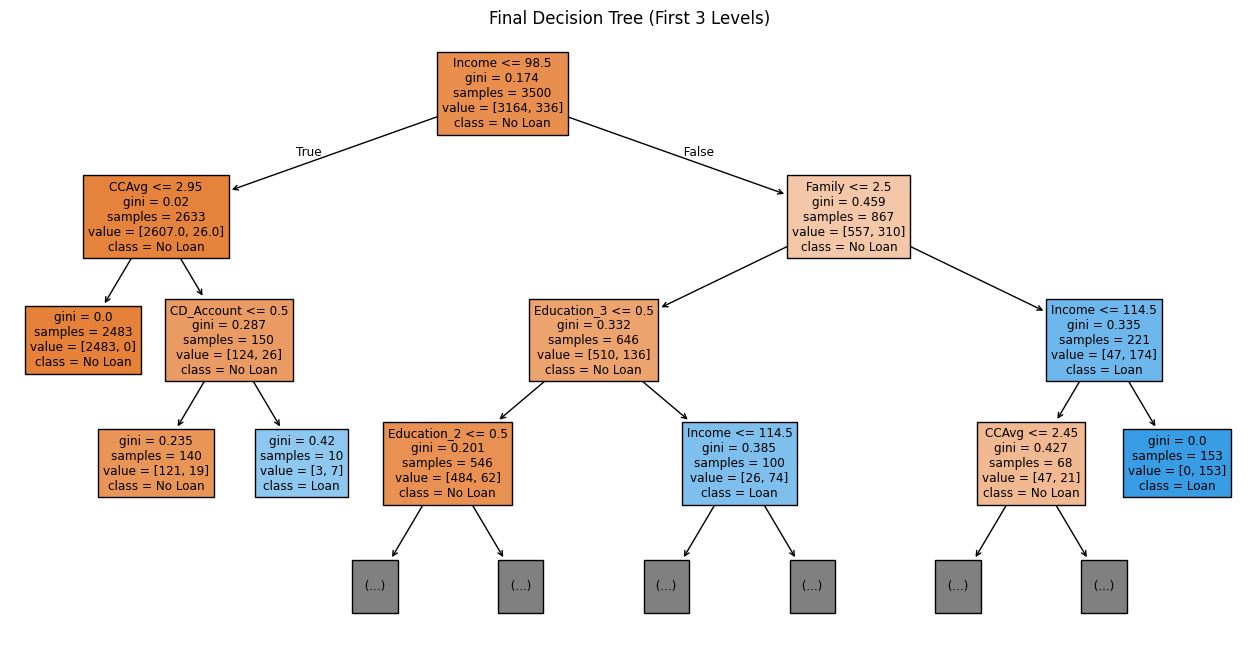

In [1321]:
# Compare feature importances for the final model
final_model = dt_postpruned 
importances_final = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances_final.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Feature Importances (Final Model)")
plt.show()

# Visualize the final tree (limited depth for clarity)
plt.figure(figsize=(16, 8))
plot_tree(final_model, feature_names=X_train.columns, class_names=["No Loan", "Loan"], filled=True, max_depth=3)
plt.title("Final Decision Tree (First 3 Levels)")
plt.show()

## Actionable Insights & Recommendations

### 1. Key Takeaways for Marketing Team
- Income, CCAvg (credit card spending), Education, and CD_Account are the most important features for predicting personal loan acceptance.
- Advise to focus on middle-aged, high-income customers with high credit card spending, especially those with higher education and existing CD or Securities Accounts.
- Customers with CD or Securities Accounts are more likely to accept loans. Advise is to target these for cross-selling.
- Modify marketing messages to highlight benefits for high-income, high-spending customers and offer them bundled products or give them incentives.

### 2. Campaign Advice
- Provide personalised loan offers for above mentioned customers that have high probabilities to accept personal loan offers.
- Design campaigns that emphasize exclusive rates, convenience, and bundled offers for customers with existing bank products.
- Monitor campaign performance and retrain the model periodically to adapt to changing customer behavior.